In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv("housing.csv")

In [23]:
# stratified shuffle split
df['income_cat']=pd.cut(df['median_income'],bins=[0,1.5,3.0,4.5,6.0,np.inf],labels=[1,2,3,4,5])

In [27]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(test_size=0.2,random_state=42,n_splits=1)
for train_index,test_index in split.split(df,df['income_cat']):
    strat_train_set=df.iloc[train_index]
    strat_test_set=df.iloc[test_index]

In [28]:
for sett in (strat_train_set,strat_test_set):
    sett.drop('income_cat',axis=1)

In [29]:
df=strat_train_set.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

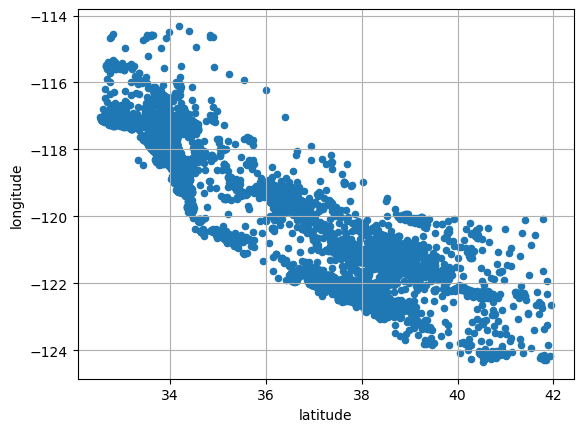

In [30]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True)

<Axes: xlabel='latitude', ylabel='longitude'>

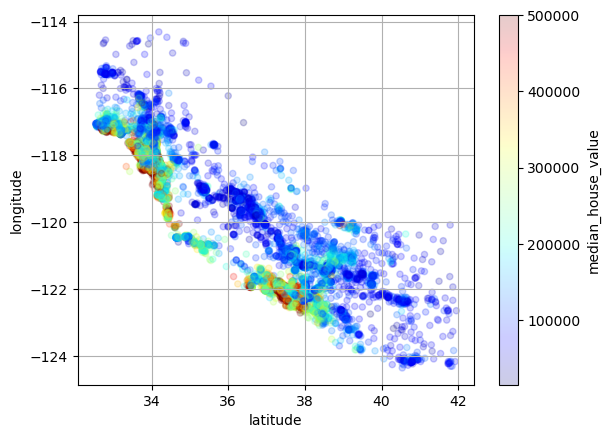

In [31]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True,cmap="jet",c="median_house_value",alpha=0.2)

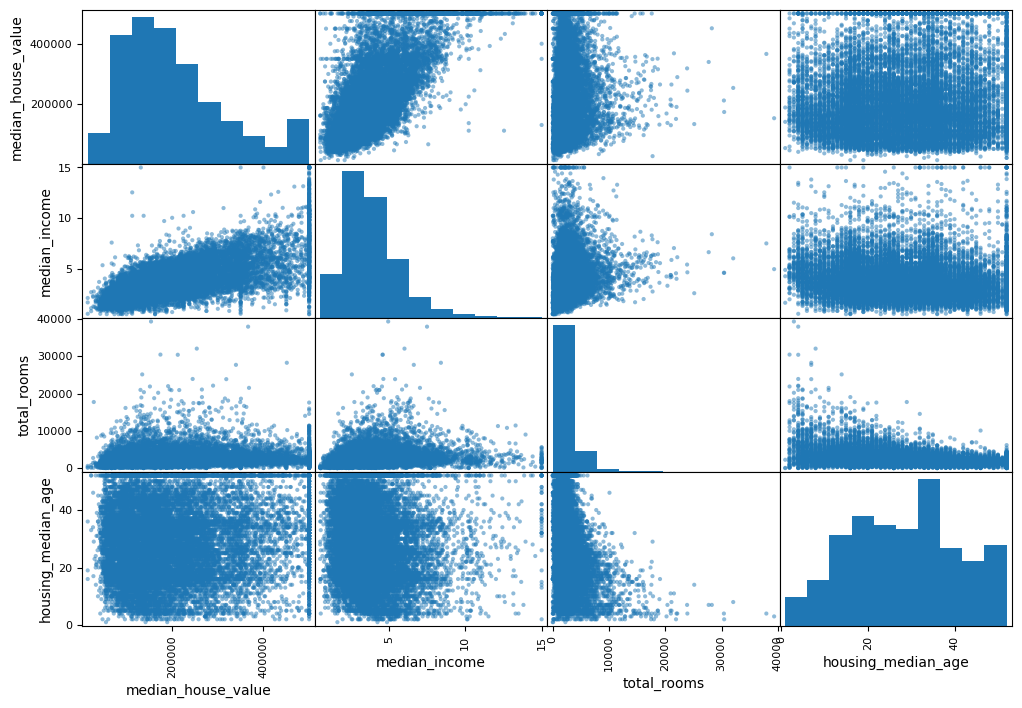

In [32]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()